In [1]:
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score, f1_score, recall_score, precision_score
from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyClassifier
from sklearn.inspection import permutation_importance
from sklearn.tree import plot_tree

import pandas as pd
import numpy as np

#Ploting Libraries
from matplotlib import pyplot as plt
import matplotlib.image as mpimg
from plotnine import *
import seaborn as sns

import tqdm as notebook_tqdm

import io

#Explanation
from ciu import CIU, ciuplots

import warnings
warnings.filterwarnings('ignore')

In [2]:
X_median = pd.read_csv('data/features_imputed_median.csv').iloc[:, 1:]
X_mice = pd.read_csv('data/features_imputed_mice.csv').iloc[:, 1:]
y = pd.read_csv('data/target.csv').iloc[:, 1:]

In [3]:
'neutrophils_max' in X_median.columns.to_list()

True

In [4]:
def train_models(X_train, X_test, y_train, y_test, reduced=False):
        
    models = {
        'dummy_classifier': DummyClassifier(strategy='most_frequent'),
        'logistic':LogisticRegression(),
        'decision_tree': DecisionTreeClassifier(max_depth=4, max_leaf_nodes=32),
        'random_forest': RandomForestClassifier(),
        'hist_gradient_boosting':HistGradientBoostingClassifier(),
        'gradient_boosting':GradientBoostingClassifier()
    }

    model_perfomance = {}
    trained_models = {}

    for model_name in models:
        model = models[model_name]
        model.fit(X_train, y_train)

        y_proba = model.predict_proba(X_test)
        y_pred = np.argmax(y_proba, axis=1)
        
        model_perfomance[model_name] = {'accuracy': accuracy_score(y_test, y_pred),
                                        'f1_score': f1_score(y_test, y_pred),
                                        'recall':recall_score(y_test, y_pred),
                                        'precision':precision_score(y_test, y_pred),
                                        'classification_report':classification_report(y_test, y_pred)
                                        }
        trained_models[model_name] = model
        
    #print(model_perfomance)
    results = pd.DataFrame(model_perfomance)
    display(results)

    return trained_models, results

In [5]:
def plot_permuted_importance(perm_imp):
    # Split top 8 vs the rest
    top8 = perm_imp.head(8)
    others = perm_imp.iloc[8:]

    # Aggregate the rest into one row
    others_row = pd.DataFrame([{
        'feature': f'All Other Features ({len(others)})',
        'importance': others['importance'].mean(),
        'std': others['std'].mean()
    }])

    # Combine and sort for plotting (smallest at top → largest at bottom for barh)
    plot_df = pd.concat([others_row, top8]).reset_index(drop=True)
    plot_df = plot_df.sort_values('importance', ascending=True)

    # Color: highlight top 8 vs the aggregated group
    colors = ['#b0b0b0'] + ['#1a6fa8'] * 8  # grey for "others", blue for top 8

    plt.figure(figsize=(10, 6))
    bars = plt.barh(
        plot_df['feature'], 
        plot_df['importance'],
        xerr=plot_df['std'],
        align='center',
        color=colors,
        edgecolor='white',
        height=0.6,
        error_kw=dict(ecolor='black', capsize=3, linewidth=0.8)
    )

    # Annotate importance values at end of each bar
    for bar, val in zip(bars, plot_df['importance']):
        plt.text(val + 0.0003, bar.get_y() + bar.get_height() / 2,
                f'{val:.4f}', va='center', ha='left', fontsize=8)

    plt.title('Permutation Importance (Top 8 Features)', fontsize=12)
    plt.xlabel('Mean Accuracy Decrease', fontsize=11)
    plt.axvline(x=0, color='black', linewidth=0.8, linestyle='--', alpha=0.4)
    plt.tight_layout()
    plt.show()

In [6]:
def choose_important_features(X_test, y_test, trained_models, model_choice):
    result = permutation_importance(trained_models[model_choice], X_test, y_test, n_repeats=10, random_state=42)

    perm_imp = pd.DataFrame({
    'feature': X_test.columns,
    'importance': result.importances_mean,
    'std': result.importances_std
        }).sort_values('importance', ascending=False)

    plot_permuted_importance(perm_imp)

    # Keep only features with positive importance
    important_features = perm_imp[perm_imp['importance'] > 0]['feature'].tolist()

    print(f"Kept {len(important_features)} of {X_test.shape[1]} features")

    return important_features

## Explainability

In [7]:
def get_indices(y_test):
    rng = np.random.default_rng(seed=42)

    indices_0 = np.where(y_test == 0)[0]
    indices_1 = np.where(y_test == 1)[0]

    resistant_indices = rng.choice(indices_1, 4)
    all_indices = rng.choice(indices_1, 1000) + rng.choice(indices_0, 1000)
    
    return resistant_indices


In [8]:
[1, 2, 3] + [2, 3]

[1, 2, 3, 2, 3]

In [9]:
def get_ciu_results(resistant_indices, model_name, X_train, X_test, trained_models):
    model = trained_models[model_name]
    CIU_amr = CIU(model.predict_proba, ['No','Yes'], data = X_train)
    CIU_amr.instance

    ciu_results = {}
    for i in resistant_indices:
        instance_1 = X_test.iloc[[i]]
        CIUres_1 = CIU_amr.explain(instance_1, output_inds=1)
        
        #Removes the really small values, pretty much because I have in some cases 119 features
        plot_df = CIUres_1[~((CIUres_1["CI"].abs() < 1e-9) & (CIUres_1["CU"].abs() < 1e-9))] 
        ciu_results[i]=plot_df #Cleaner datagframe for plotting

    return ciu_results, CIU_amr

In [ ]:
def plot_ciu_instances(ciu_results, CIU_amr):
    keys = list(ciu_results.keys())
    fig, axes = plt.subplots(2, 2, figsize=(12, 20))
    axes = axes.flatten()

    for i, key in enumerate(keys):
        result = ciu_results[key]
        
        # plot_ciu renders internally — grab the figure it just created
        CIU_amr.plot_ciu(result, plot_mode="overlap", figsize=(6, 12))
        p = plt.gcf()  # <-- capture whatever figure is currently active
        
        # Capture it to a buffer
        buf = io.BytesIO()
        p.savefig(buf, format="png", bbox_inches="tight")
        buf.seek(0)
        plt.close(p)  # close the internal figure
        
        # Paste into the subplot as an image
        img = mpimg.imread(buf)
        axes[i].imshow(img)
        axes[i].axis("off")
        axes[i].set_title(f"Instance {key} Probability {list(result.outval)[0]:.2f}")

    # Hide unused axes
    for j in range(len(keys), len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout(h_pad=1.0)
    plt.show()
    return

In [11]:
def plot_ci_instances(ciu_results, CIU_amr):
    keys = list(ciu_results.keys())
    fig, axes = plt.subplots(2, 2, figsize=(12, 20))
    axes = axes.flatten()

    for i, key in enumerate(keys):
        result = ciu_results[key]
        
        # plot_ciu renders internally — grab the figure it just created
        CIU_amr.plot_influence(result, figsize=(6, 12))
        p = plt.gcf()  # <-- capture whatever figure is currently active
        
        # Capture it to a buffer
        buf = io.BytesIO()
        p.savefig(buf, format="png", bbox_inches="tight")
        buf.seek(0)
        plt.close(p)  # close the internal figure
        
        # Paste into the subplot as an image
        img = mpimg.imread(buf)
        axes[i].imshow(img)
        axes[i].axis("off")
        axes[i].set_title(f"Instance {key}")

    # Hide unused axes
    for j in range(len(keys), len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout(h_pad=1.0)
    plt.show()
    return

In [12]:
def plot_explain_all(CIUres):
    fig = ciuplots.ciu_beeswarm(CIUres,xcol='Cinfl',  legend_title='Value scale')
    fig.update_layout(height=600, width=900, margin=dict(l=20, r=20, t=50, b=20))
    fig.update_layout(
        title='CInfl versus input value for all features',
        xaxis=dict(title='Contextual Influence (CInf)'),
        yaxis=dict(title='Feature'),
    )
    fig.show()


    fig = ciuplots.ciu_beeswarm(CIUres,  legend_title='Value scale')
    fig.update_layout(height=600, width=900, margin=dict(l=20, r=20, t=50, b=20))
    fig.update_layout(
        title='CI versus input value for all features',
        xaxis=dict(title='Contextual Importance (CI)'),
        yaxis=dict(title='Feature'),
    )
    fig.show()

    fig = ciuplots.ciu_beeswarm(CIUres, xcol='CU', legend_title='Value scale')
    fig.update_layout(height=600, width=900, margin=dict(l=20, r=20, t=20, b=20), 
                      xaxis=dict(title='Contextual Utility (CU)'))
    fig.show()


## Putting Everything together

In [13]:
def feature_selection_train_pipeline(X, y, model_name, reduced=False,  explain_all=False):
    
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42
    )

    trained_models, results = train_models(X_train, X_test, y_train, y_test, reduced=False)
    
    CIU_amr = False
    resistant_indices = False

    if not reduced:
        resistant_indices = get_indices(y_test)
        ciu_results, CIU_amr = get_ciu_results(resistant_indices, model_name, X_train, X_test, trained_models)
        plot_ciu_instances(ciu_results, CIU_amr)

        if explain_all:

            CIUres = CIU_amr.explain_all(X_test.iloc[resistant_indices], output_inds=1, do_norm_invals=True)
            plot_explain_all(CIUres)

            #CIUres.to_csv('data/ciu_score.csv')

        return X_test, trained_models, results, CIU_amr, resistant_indices
    
    important_features = choose_important_features(X_test, y_test, trained_models, model_name)

    return X[important_features], trained_models, results, CIU_amr, resistant_indices

,dummy_classifier,logistic,decision_tree,random_forest,hist_gradient_boosting,gradient_boosting
accuracy,0.49975,0.665917,0.662667,0.681917,0.685,0.681667
f1_score,0.0,0.619748,0.658857,0.678243,0.680311,0.676271
recall,0.0,0.544228,0.651174,0.670165,0.669998,0.664668
precision,0.0,0.719604,0.666724,0.686519,0.690947,0.688287
classification_report,precision recall f1-score ...,precision recall f1-score ...,precision recall f1-score ...,precision recall f1-score ...,precision recall f1-score ...,precision recall f1-score ...


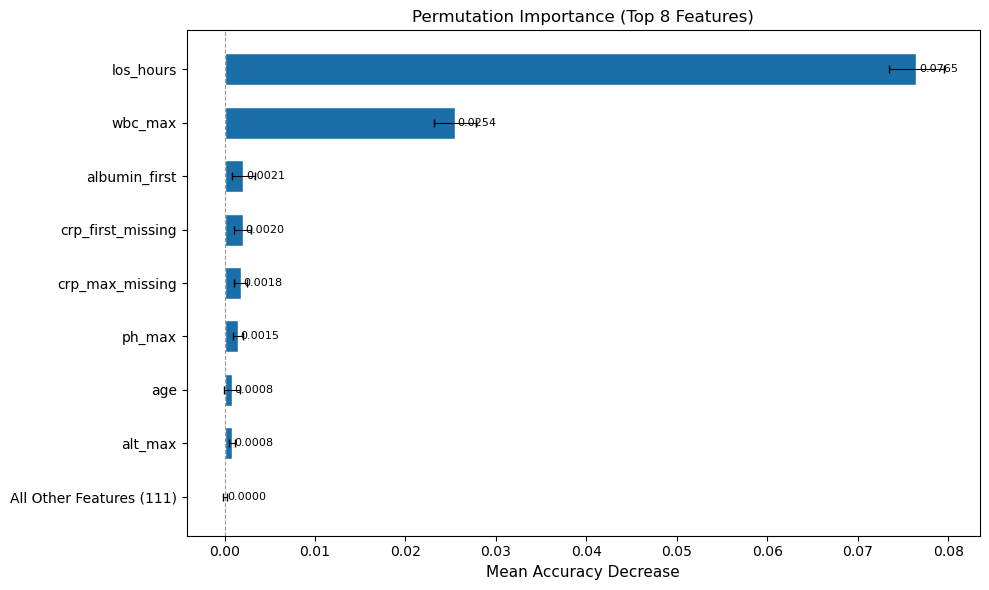

Kept 53 of 119 features


In [14]:
X_reduced, trained_models, results, CIU_amr, resistant_indices = feature_selection_train_pipeline(X_median, y,model_name='gradient_boosting',reduced= True)

,dummy_classifier,logistic,decision_tree,random_forest,hist_gradient_boosting,gradient_boosting
accuracy,0.49975,0.66275,0.662667,0.68275,0.684,0.680583
f1_score,0.0,0.618962,0.658857,0.678978,0.679892,0.674203
recall,0.0,0.54756,0.651174,0.670665,0.670831,0.66067
precision,0.0,0.71178,0.666724,0.6875,0.689201,0.688303
classification_report,precision recall f1-score ...,precision recall f1-score ...,precision recall f1-score ...,precision recall f1-score ...,precision recall f1-score ...,precision recall f1-score ...


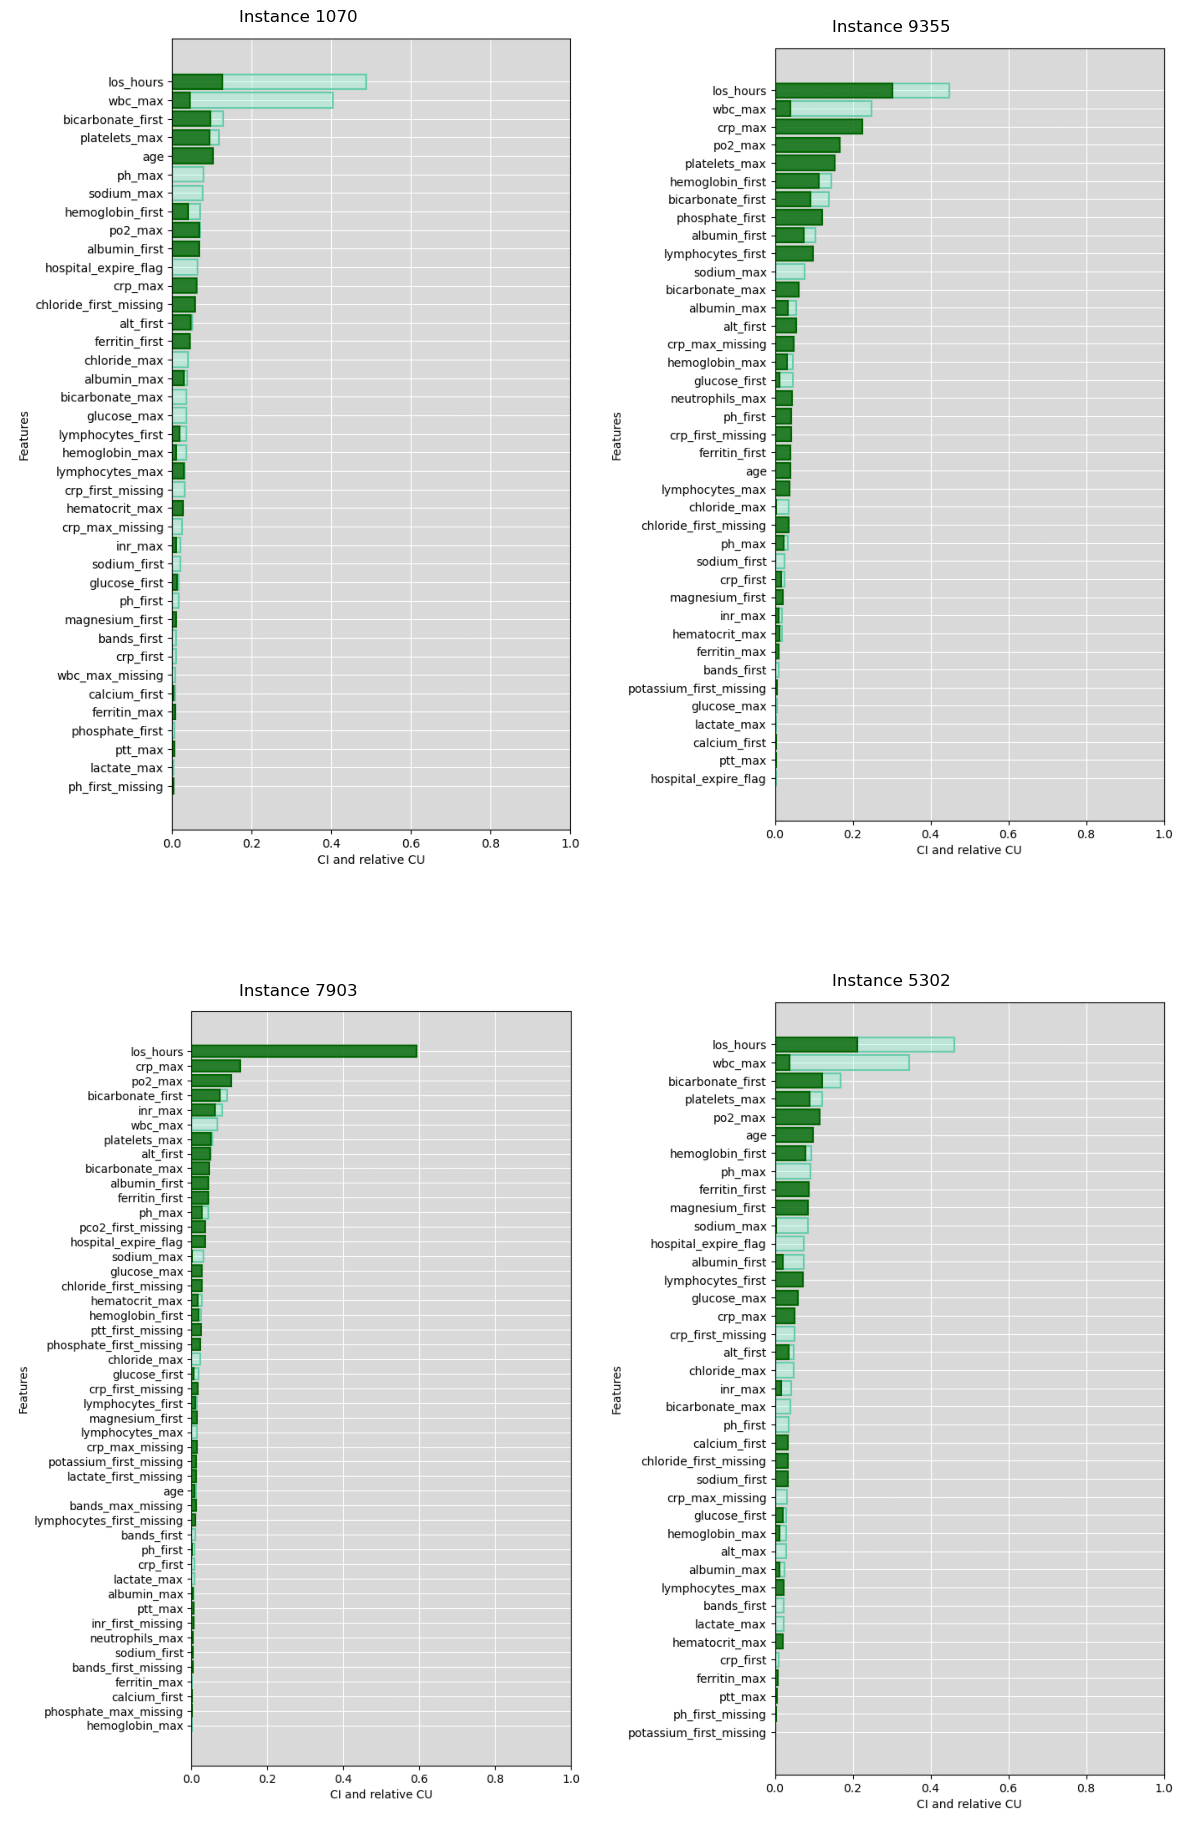

In [15]:
X_test, trained_models, results, CIU_amr, resistant_indices = feature_selection_train_pipeline(X_reduced, y, model_name='gradient_boosting', reduced=False)

In [16]:
# Removing Length of Stay (LOS)
X_los_dropped = X_median.drop(columns='los_hours')

,dummy_classifier,logistic,decision_tree,random_forest,hist_gradient_boosting,gradient_boosting
accuracy,0.49975,0.633833,0.638917,0.6695,0.675417,0.66625
f1_score,0.0,0.575623,0.601343,0.665203,0.668933,0.653816
recall,0.0,0.496418,0.544394,0.656338,0.655506,0.630018
precision,0.0,0.6849,0.671599,0.674311,0.682923,0.679483
classification_report,precision recall f1-score ...,precision recall f1-score ...,precision recall f1-score ...,precision recall f1-score ...,precision recall f1-score ...,precision recall f1-score ...


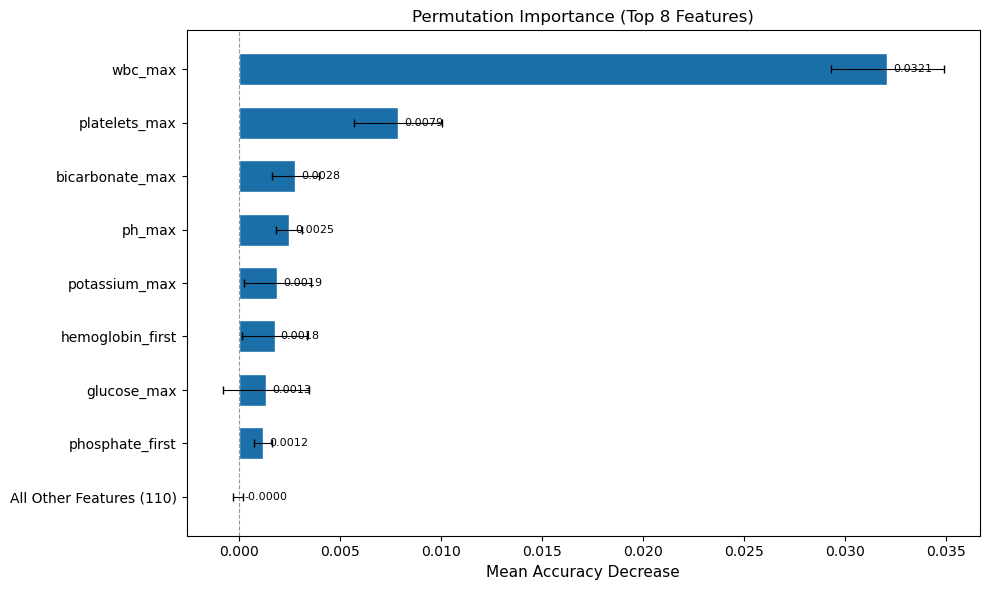

Kept 37 of 118 features


In [17]:
X_reduced_los_dropped, trained_models, results, CIU_amr, resistant_indices = feature_selection_train_pipeline(X=X_los_dropped, 
                                                                                                   y=y, 
                                                                                                   model_name='gradient_boosting',
                                                                                                   reduced=True, explain_all=False)

,dummy_classifier,logistic,decision_tree,random_forest,hist_gradient_boosting,gradient_boosting
accuracy,0.49975,0.64525,0.633667,0.658667,0.673,0.66925
f1_score,0.0,0.596225,0.574361,0.653762,0.665872,0.658228
recall,0.0,0.523572,0.494086,0.644178,0.651341,0.636682
precision,0.0,0.692291,0.68578,0.663635,0.681066,0.681283
classification_report,precision recall f1-score ...,precision recall f1-score ...,precision recall f1-score ...,precision recall f1-score ...,precision recall f1-score ...,precision recall f1-score ...


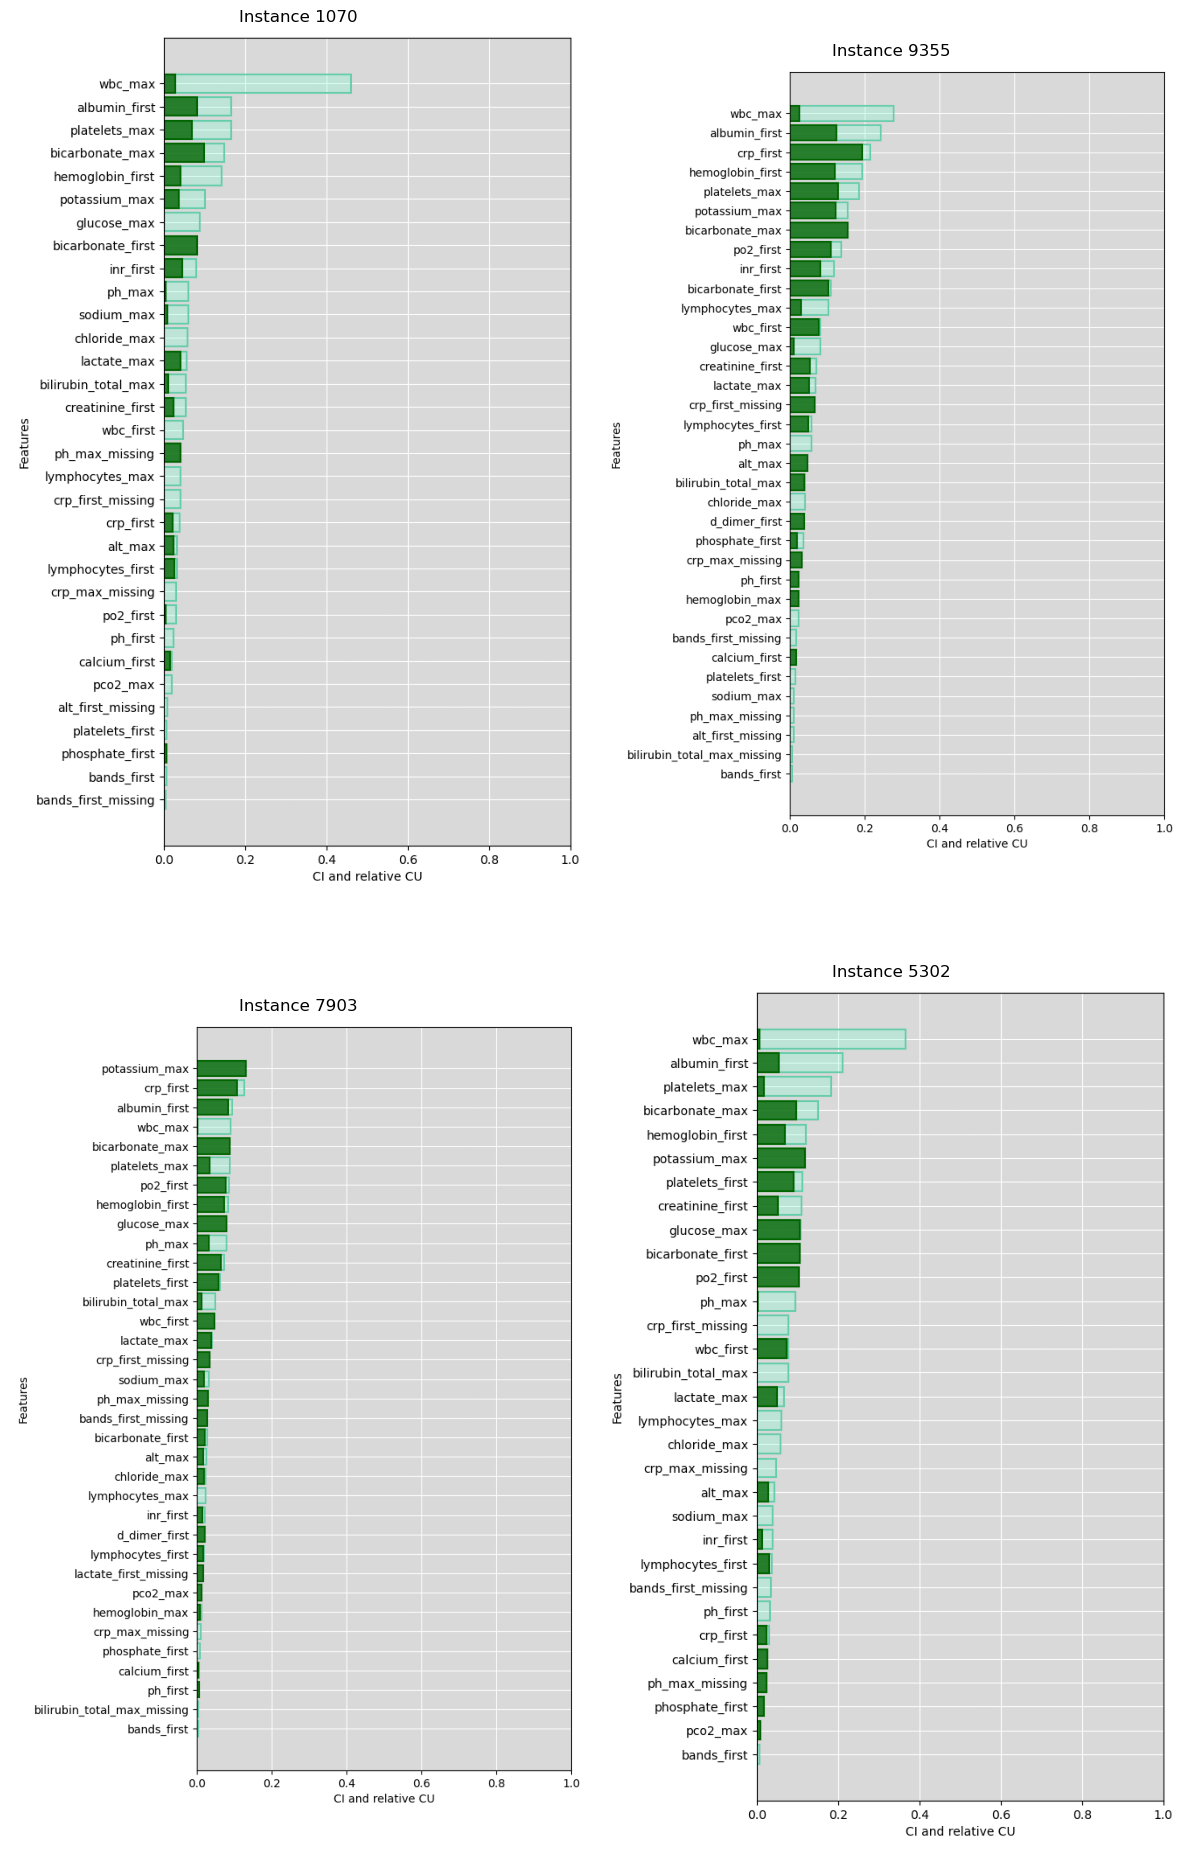

In [18]:
X_test, trained_models, results,CIU_amr, resistant_indices = feature_selection_train_pipeline( X=X_reduced_los_dropped, 
                                                                    y=y, 
                                                                    model_name='gradient_boosting',
                                                                    reduced=False, 
                                                                    explain_all=False)

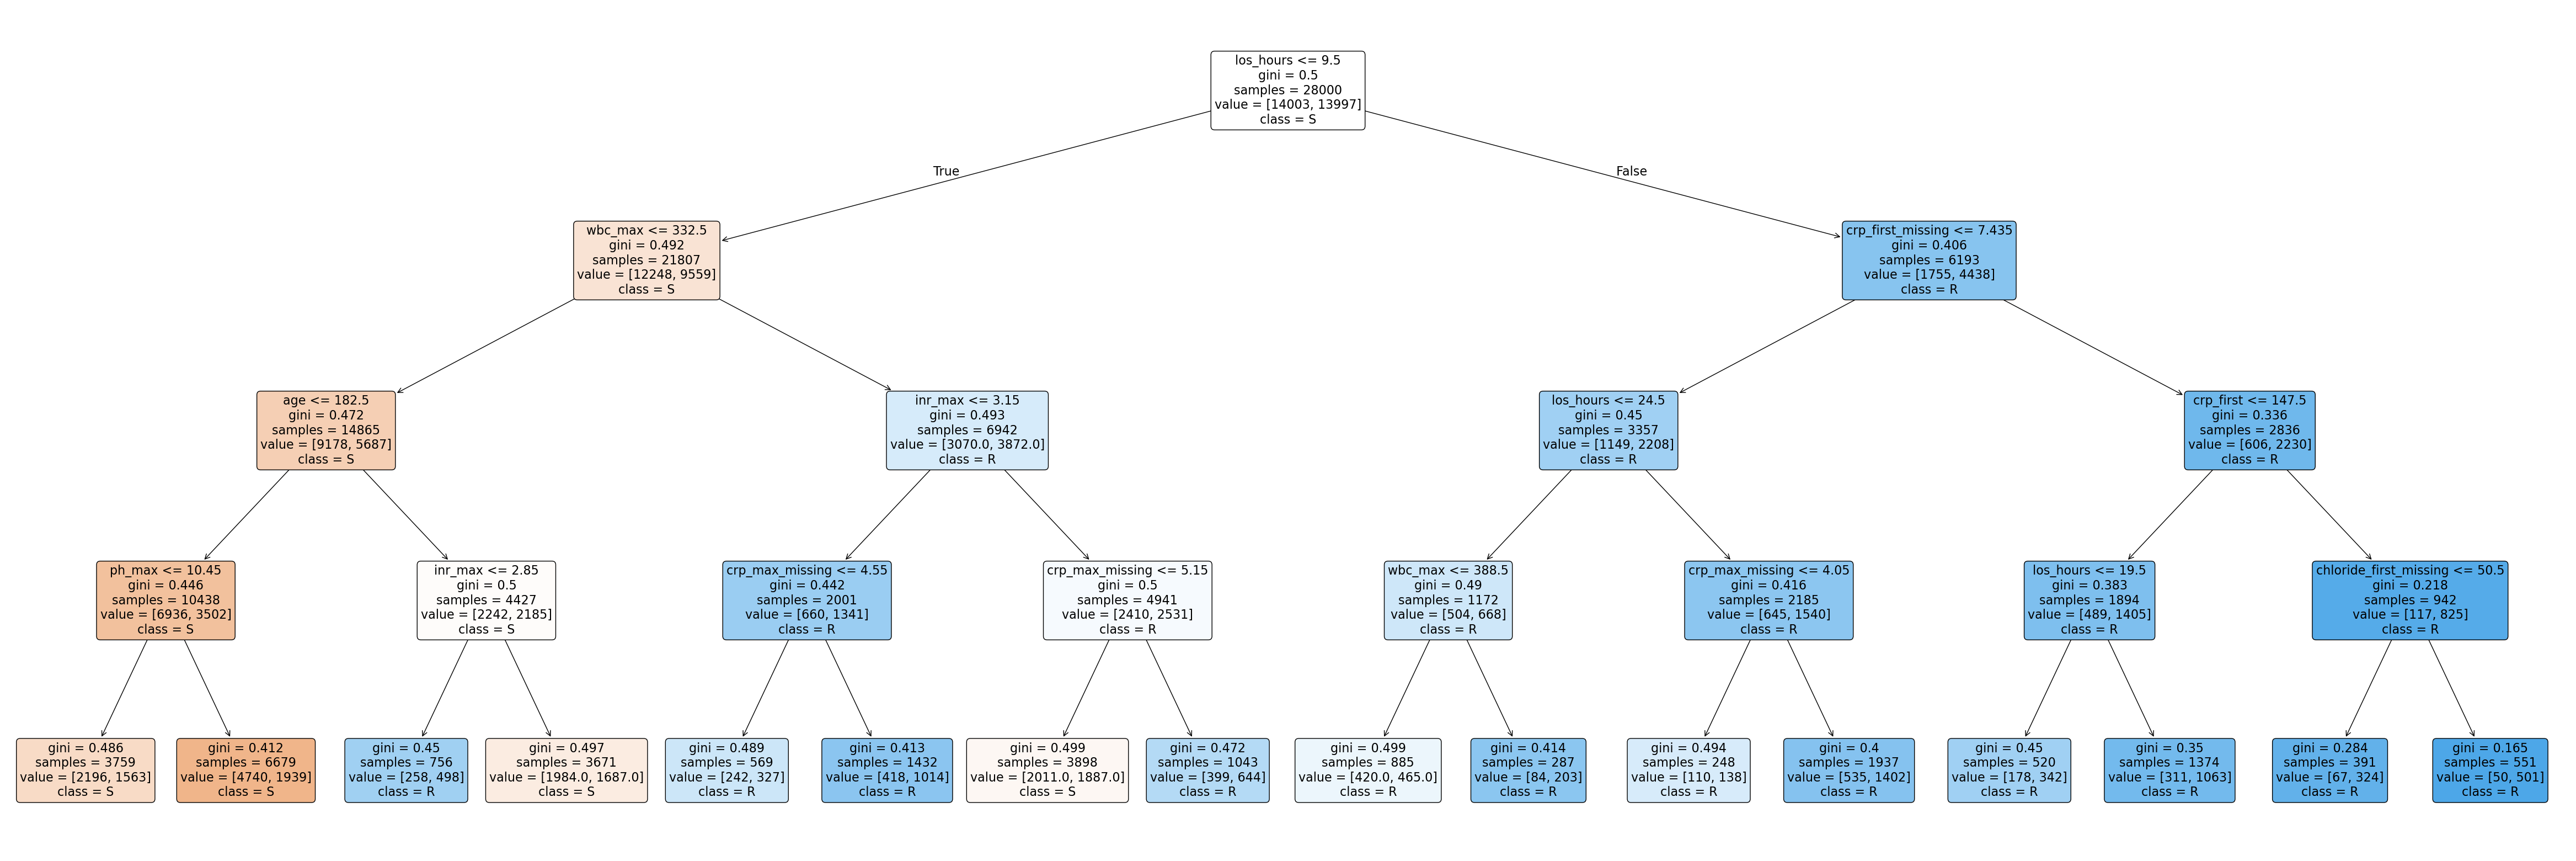

In [19]:
def plot_tree_from_output():
    fig, ax = plt.subplots(figsize=(60, 20))
    plot_tree(
        trained_models['decision_tree'],       # your fitted DecisionTreeClassifier
        feature_names=X_reduced.columns.tolist(),
        class_names=['S', 'R'],
        filled=True,                    # colour nodes by class
        rounded=True,
        fontsize=16,
        ax=ax
    )
    plt.savefig('decision_tree.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_tree_from_output()

In [20]:
results = results.T

In [21]:
print(results.classification_report.loc['decision_tree'])

              precision    recall  f1-score   support

           0       0.60      0.77      0.68      5997
           1       0.69      0.49      0.57      6003

    accuracy                           0.63     12000
   macro avg       0.65      0.63      0.63     12000
weighted avg       0.65      0.63      0.63     12000



In [22]:
amr_voc = {
    "InflammatoryResponse": [
        'wbc_first', 'wbc_max',
        'neutrophils_first', 'neutrophils_max',
        'monocytes_first', 'monocytes_max',
        'bands_first', 'bands_max',
        'lymphocytes_first', 'lymphocytes_max',
        'crp_first', 'crp_max',
        'ferritin_first', 'ferritin_max'
    ],
    "AcidBaseRespiratory": [
        'ph_first', 'ph_max',
        'pco2_first', 'pco2_max',
        'po2_first', 'po2_max',
        'bicarbonate_first', 'bicarbonate_max'
    ],
    "MetabolicFunction": [
        'glucose_first', 'glucose_max',
        'lactate_first', 'lactate_max'
    ],
    "RenalFunction": [
        'creatinine_first', 'creatinine_max'
    ],
    "ElectrolyteBalance": [
        'sodium_first', 'sodium_max',
        'potassium_first', 'potassium_max',
        'chloride_first', 'chloride_max',
        'calcium_first', 'calcium_max',
        'magnesium_first', 'magnesium_max',
        'phosphate_first', 'phosphate_max'
    ],
    "HepaticNutritionalStatus": [
        'alt_first', 'alt_max',
        'albumin_first', 'albumin_max',
        'bilirubin_total_first', 'bilirubin_total_max'
    ],
    "HematologicalProfile": [
        'hemoglobin_first', 'hemoglobin_max',
        'hematocrit_first', 'hematocrit_max',
        'platelets_first', 'platelets_max'
    ],
    "CoagulationStatus": [
        'inr_first', 'inr_max',
        'ptt_first', 'ptt_max',
        'd_dimer_first', 'd_dimer_max'
    ],
    "PatientDemographics": [
        'age', 'los_hours'
    ],
    "DataMissingness": [
        'wbc_first_missing', 'wbc_max_missing',
        'bands_first_missing', 'bands_max_missing',
        'neutrophils_first_missing', 'neutrophils_max_missing',
        'lymphocytes_first_missing', 'lymphocytes_max_missing',
        'monocytes_first_missing', 'monocytes_max_missing',
        'crp_first_missing', 'crp_max_missing',
        'ferritin_first_missing', 'ferritin_max_missing',
        'lactate_first_missing', 'lactate_max_missing',
        'creatinine_first_missing', 'creatinine_max_missing',
        'bilirubin_total_first_missing', 'bilirubin_total_max_missing',
        'alt_first_missing', 'alt_max_missing',
        'albumin_first_missing', 'albumin_max_missing',
        'glucose_first_missing', 'glucose_max_missing',
        'inr_first_missing', 'inr_max_missing',
        'ptt_first_missing', 'ptt_max_missing',
        'platelets_first_missing', 'platelets_max_missing',
        'd_dimer_first_missing', 'd_dimer_max_missing',
        'ph_first_missing', 'ph_max_missing',
        'po2_first_missing', 'po2_max_missing',
        'pco2_first_missing', 'pco2_max_missing',
        'bicarbonate_first_missing', 'bicarbonate_max_missing',
        'hemoglobin_first_missing', 'hemoglobin_max_missing',
        'hematocrit_first_missing', 'hematocrit_max_missing',
        'sodium_first_missing', 'sodium_max_missing',
        'potassium_first_missing', 'potassium_max_missing',
        'chloride_first_missing', 'chloride_max_missing',
        'calcium_first_missing', 'calcium_max_missing',
        'magnesium_first_missing', 'magnesium_max_missing',
        'phosphate_first_missing', 'phosphate_max_missing'
    ]
}

In [23]:
def intermediate_concepts_results(resistant_indices, X_test, voc, CIU_amr):
    CIU_amr.vocabulary = voc
    ciu_intermidiate_results = {}
    for i in resistant_indices:
        instance_1 = X_test.iloc[[i]]
        top_res = CIU_amr.explain_voc(instance_1, output_inds=1, nsamples=1000)
        #display(top_res)
        ciu_intermidiate_results[i]=top_res

    return ciu_intermidiate_results

In [24]:
def filter_voc(voc: dict, curr_list: list) -> dict:
    curr_set = set(curr_list)
    filtered_voc = {
        concept: [f for f in features if f in curr_set]
        for concept, features in voc.items()
    }
    # Drop concepts that end up empty
    return {concept: features for concept, features in filtered_voc.items() if features}

amr_voc_filtered = filter_voc(amr_voc, X_test.columns)

In [25]:
ciu_intermidiate_results =  intermediate_concepts_results(resistant_indices, X_test, amr_voc_filtered, CIU_amr)

In [46]:
ciu_intermidiate_results[1070]

,CI,CU,Cinfl,outname,outval,feature,ymin,ymax,inputs,invals,neutralCU,target_concept,target_inputs
InflammatoryResponse,0.567934,0.125823,-0.212508,Yes,0.304706,InflammatoryResponse,0.233247,0.801181,"[22, 0, 30, 21, 11, 23]","[5.0, 9.0, 1.0, 31.7, 31.7, 65.35]",0.5,None,None
AcidBaseRespiratory,0.372082,0.463670,-0.013518,Yes,0.304706,AcidBaseRespiratory,0.132183,0.504264,"[28, 3, 26, 25, 31, 2]","[7.5, 7.5, 45.0, 90.0, 28.0, 28.0]",0.5,None,None
MetabolicFunction,0.146460,0.279972,-0.032225,Yes,0.304706,MetabolicFunction,0.263701,0.410162,"[6, 27, 36]","[96.0, 1.5, 1.5]",0.5,None,None
creatinine_first,0.053144,0.429431,-0.003750,Yes,0.304706,creatinine_first,0.281884,0.335029,[18],[0.5],0.5,None,None
ElectrolyteBalance,0.290576,0.341146,-0.046159,Yes,0.304706,ElectrolyteBalance,0.205577,0.496154,"[17, 4, 20, 12, 7]","[145.0, 4.4, 107.0, 8.1, 2.5]",0.5,None,None
HepaticNutritionalStatus,0.253618,0.443849,-0.014241,Yes,0.304706,HepaticNutritionalStatus,0.192138,0.445756,"[34, 19, 29]","[70.0, 3.3, 0.2]",0.5,None,None
HematologicalProfile,0.397010,0.409895,-0.035772,Yes,0.304706,HematologicalProfile,0.141973,0.538984,"[5, 24, 10, 1]","[12.9, 12.9, 272.0, 318.0]",0.5,None,None
CoagulationStatus,0.080729,0.550414,0.004070,Yes,0.304706,CoagulationStatus,0.260272,0.341001,"[15, 33]","[1.2, 1863.5]",0.5,None,None
DataMissingness,0.138840,0.301667,-0.027536,Yes,0.304706,DataMissingness,0.262823,0.401662,"[32, 13, 8, 35, 14, 16, 9]","[1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0]",0.5,None,None


In [48]:
list(ciu_intermidiate_results[9355].outval)[0]

0.5923717393870634

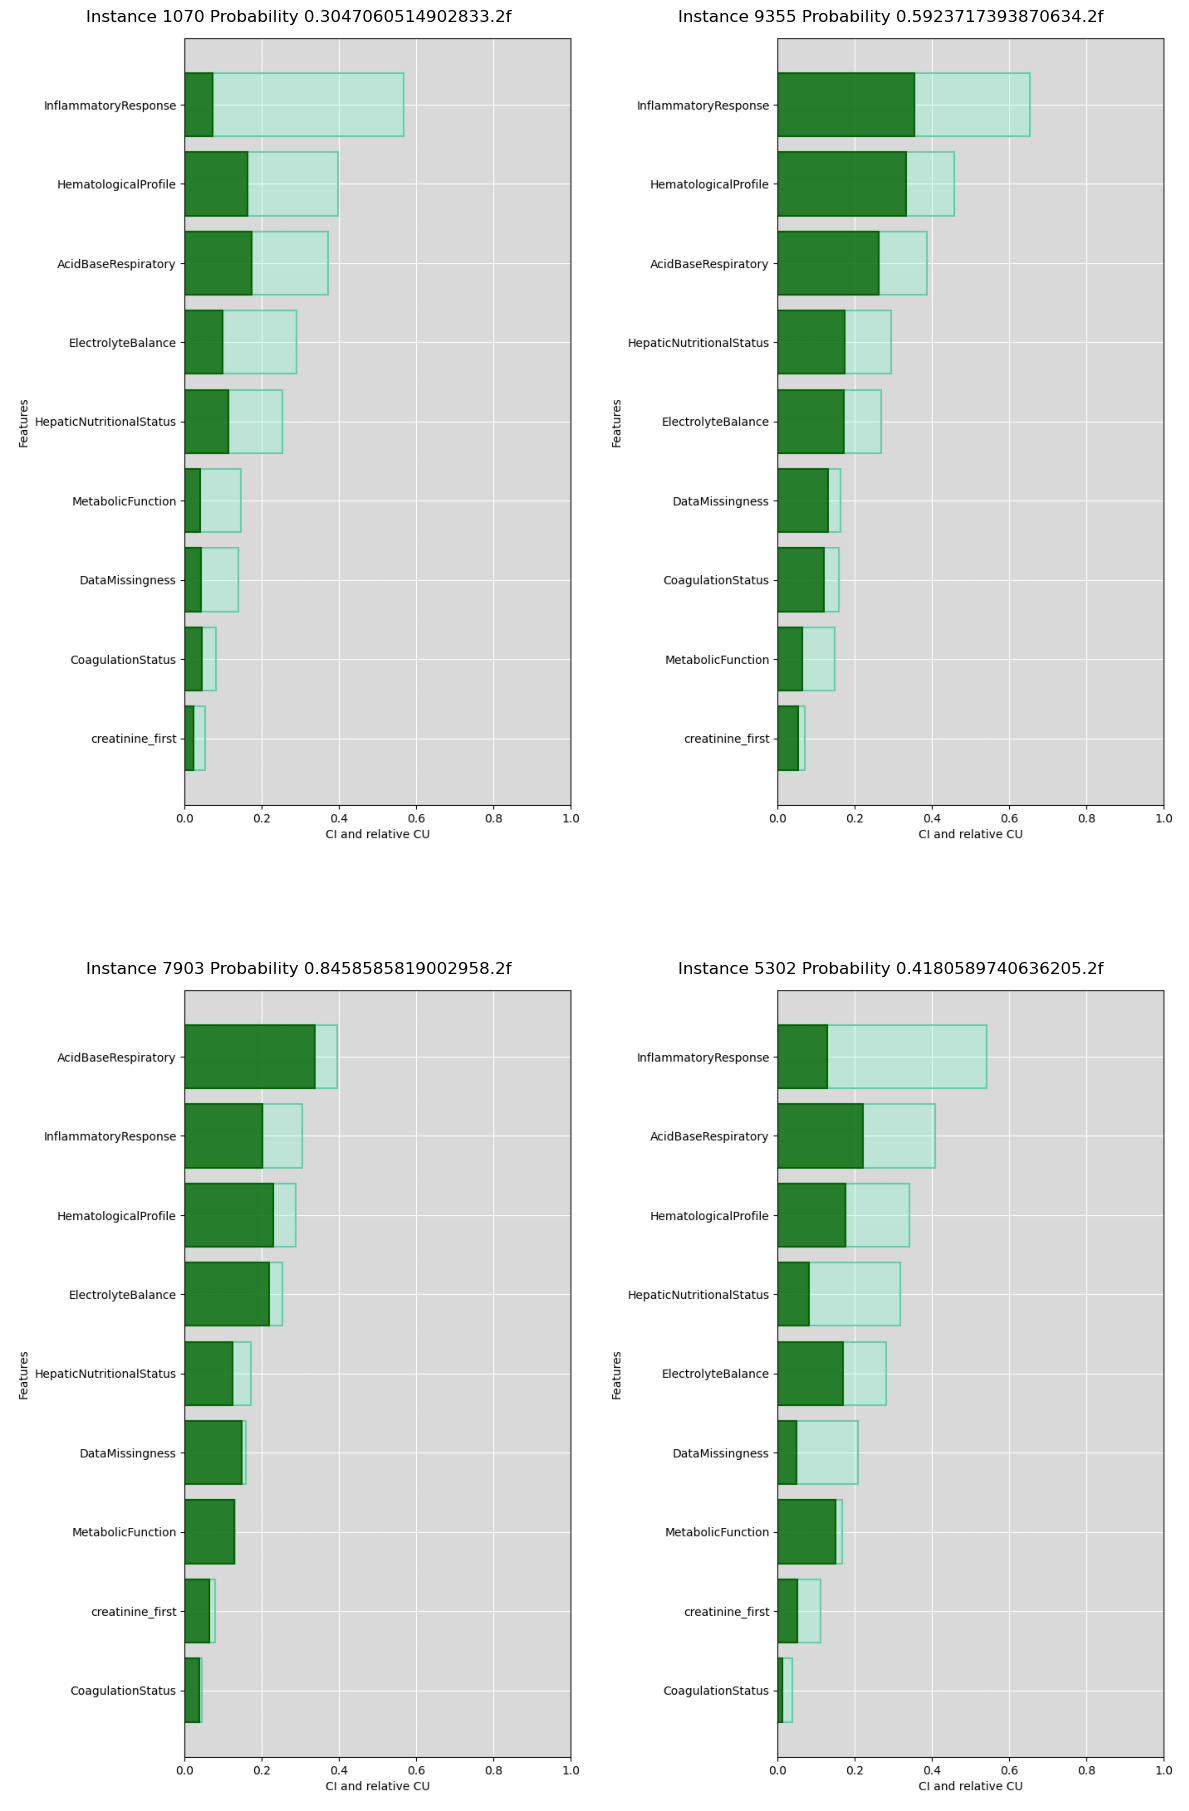

In [52]:
plot_ciu_instances(ciu_intermidiate_results, CIU_amr)

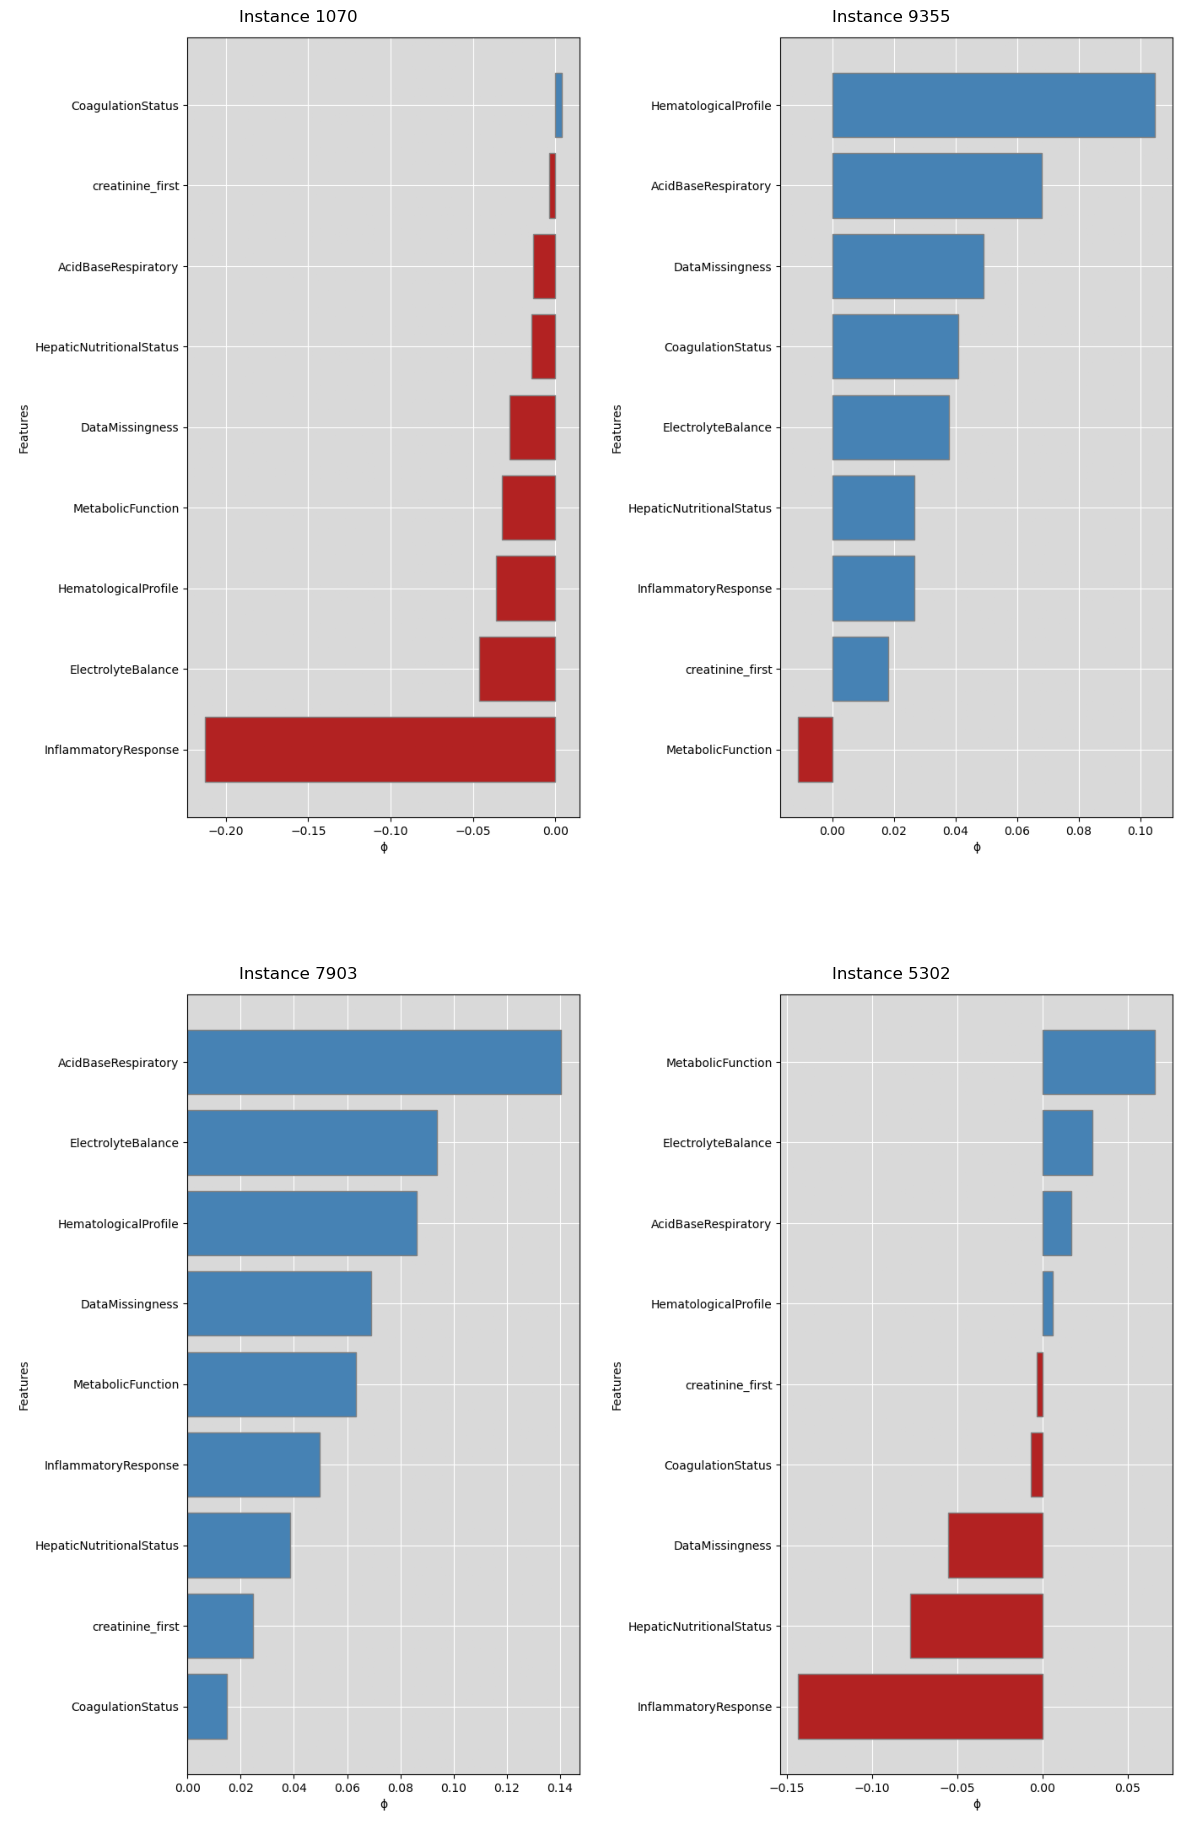

In [27]:
plot_ci_instances(ciu_intermidiate_results, CIU_amr)

In [28]:
X_test

,wbc_max,platelets_max,bicarbonate_max,ph_max,potassium_max,hemoglobin_first,glucose_max,phosphate_first,crp_max_missing,ph_max_missing,...,lactate_first,ph_first,bilirubin_total_max,bands_first,bicarbonate_first,bands_first_missing,d_dimer_first,alt_max,lactate_first_missing,lactate_max
32823,9.0,317.0,30.0,7.44,6.4,7.9,397.0,5.8,0.0,0.0,...,0.4,7.08,0.2,1.0,26.0,1.0,1863.5,17.0,0.0,0.4
16298,9.0,174.0,26.0,7.44,4.0,13.1,119.0,3.8,1.0,0.0,...,0.8,7.38,0.5,1.0,22.0,1.0,1863.5,20.0,0.0,0.8
28505,9.0,379.0,27.0,6.50,4.4,9.5,129.0,3.4,1.0,0.0,...,1.6,5.00,0.6,1.0,27.0,1.0,1863.5,29.0,1.0,2.0
6689,9.0,108.0,31.0,7.38,4.6,9.8,344.0,3.1,0.0,1.0,...,1.6,6.50,0.3,1.0,27.0,1.0,1863.5,19.0,1.0,2.0
26893,2.0,268.0,31.0,8.50,6.2,8.9,266.0,7.9,0.0,0.0,...,1.6,8.50,0.6,1.0,21.0,1.0,1863.5,29.0,1.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3779,9.0,147.0,23.0,7.38,4.4,9.3,159.0,2.3,1.0,1.0,...,1.6,6.50,1.2,1.0,20.0,1.0,1863.5,66.0,1.0,2.0
11973,9.0,241.0,27.0,7.38,3.4,13.8,208.0,4.0,1.0,1.0,...,1.6,6.50,0.6,1.0,27.0,1.0,1863.5,29.0,1.0,2.0
35668,9.0,201.0,32.0,7.47,3.8,12.2,144.0,4.1,1.0,0.0,...,1.8,6.50,0.5,1.0,32.0,1.0,1863.5,27.0,0.0,1.8
483,8.0,670.0,31.0,7.42,6.0,13.8,898.0,2.9,1.0,0.0,...,1.9,5.50,1.7,1.0,31.0,1.0,1863.5,11.0,0.0,2.6


In [29]:
instance_1 = X_test.iloc[[7903]]
top_res = ciu_intermidiate_results[7903]

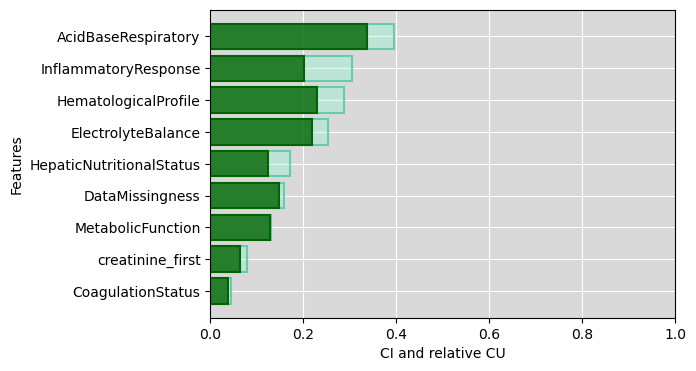

In [30]:

p = CIU_amr.plot_ciu(top_res, plot_mode='overlap')

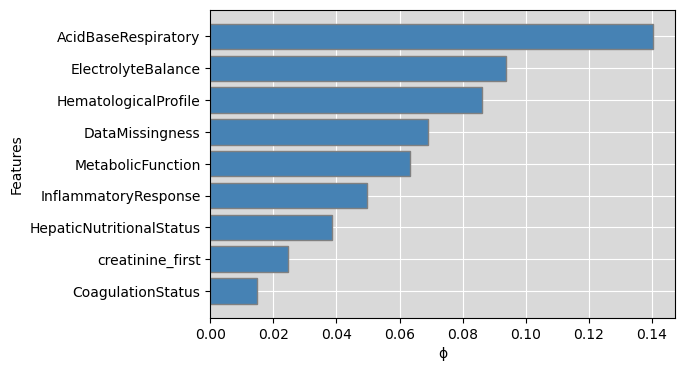

In [31]:
CIU_amr.plot_influence(top_res)

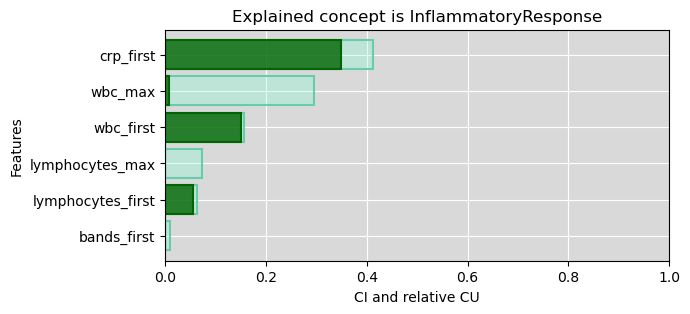

In [32]:
concept = "InflammatoryResponse"
res =   CIU_amr.explain(instance_1, output_inds=1, target_concept=concept, target_ciu=top_res, nsamples=1000)

p = CIU_amr.plot_ciu(res, figsize=(6.5,3), plot_mode='overlap', main=f"Explained concept is {concept}")

,dummy_classifier,logistic,decision_tree,random_forest,hist_gradient_boosting,gradient_boosting
accuracy,0.49975,0.64525,0.633667,0.661917,0.670833,0.66925
f1_score,0.0,0.596225,0.574361,0.657029,0.663944,0.658228
recall,0.0,0.523572,0.494086,0.647343,0.650008,0.636682
precision,0.0,0.692291,0.68578,0.66701,0.678491,0.681283
classification_report,precision recall f1-score ...,precision recall f1-score ...,precision recall f1-score ...,precision recall f1-score ...,precision recall f1-score ...,precision recall f1-score ...


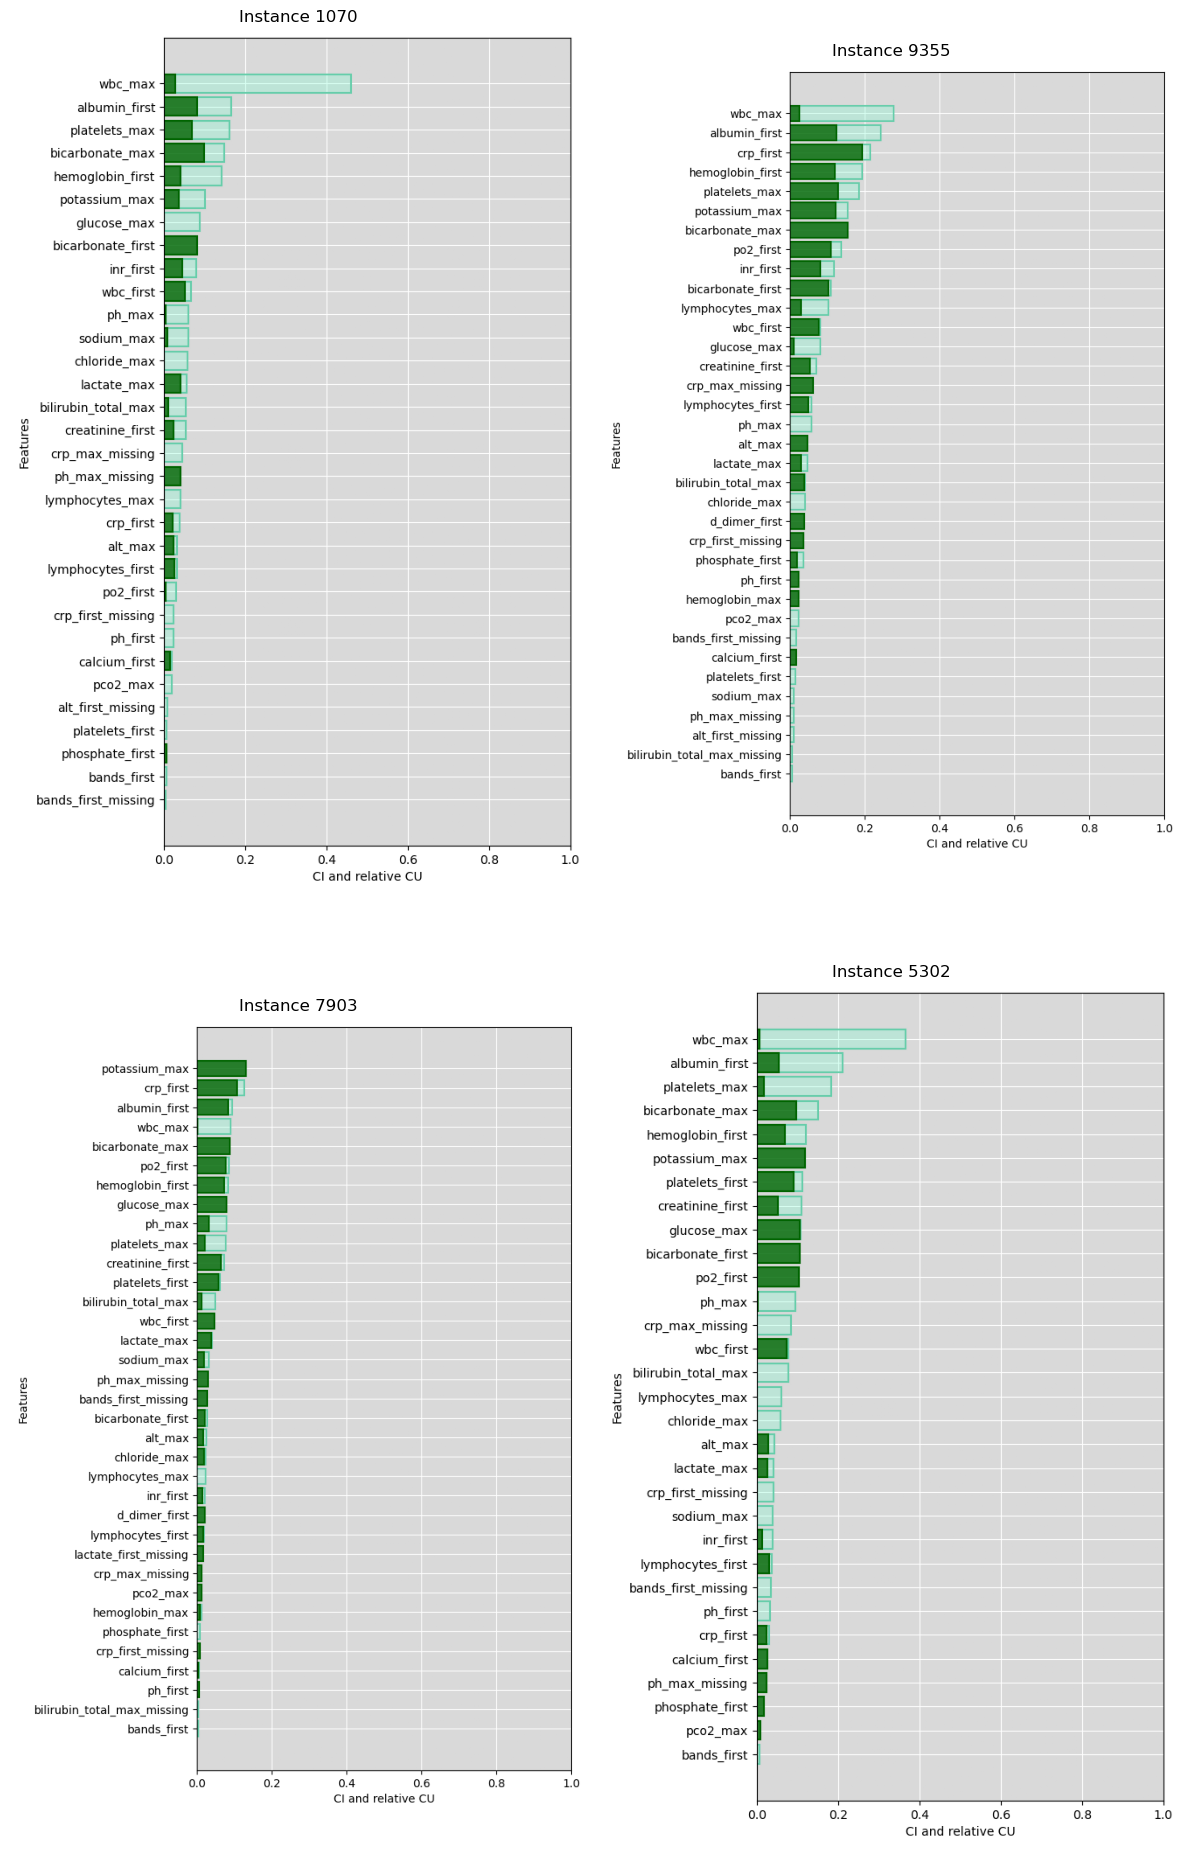

(       wbc_max  platelets_max  bicarbonate_max  ph_max  potassium_max  \
 32823      9.0          317.0             30.0    7.44            6.4   
 16298      9.0          174.0             26.0    7.44            4.0   
 28505      9.0          379.0             27.0    6.50            4.4   
 6689       9.0          108.0             31.0    7.38            4.6   
 26893      2.0          268.0             31.0    8.50            6.2   
 ...        ...            ...              ...     ...            ...   
 3779       9.0          147.0             23.0    7.38            4.4   
 11973      9.0          241.0             27.0    7.38            3.4   
 35668      9.0          201.0             32.0    7.47            3.8   
 483        8.0          670.0             31.0    7.42            6.0   
 1380       9.0          199.0             30.0    6.50            3.7   
 
        hemoglobin_first  glucose_max  phosphate_first  crp_max_missing  \
 32823               7.9        397

In [33]:
feature_selection_train_pipeline(   X=X_reduced_los_dropped, 
                                    y=y, 
                                    model_name='gradient_boosting',
                                    reduced=False, 
                                    explain_all=False)

## Break Down

,accuracy,f1_score,recall,precision,classification_report
dummy_classifier,0.49975,0.0,0.0,0.0,precision recall f1-score ...
logistic,0.64525,0.596225,0.523572,0.692291,precision recall f1-score ...
decision_tree,0.633667,0.574361,0.494086,0.68578,precision recall f1-score ...
random_forest,0.658667,0.653762,0.644178,0.663635,precision recall f1-score ...
hist_gradient_boosting,0.673,0.665872,0.651341,0.681066,precision recall f1-score ...
gradient_boosting,0.66925,0.658228,0.636682,0.681283,precision recall f1-score ...
